In [5]:
from IPython.display import clear_output
import time
import pandas as pd
from Chandelier_ZLSMA_Filter_Future import *
from Chandelier_ZLSMA import *
from Support_Resistance_Future_Scaner import *
from Display_Future import *
from Buy_Sell_Presure_Scaner import *

In [3]:
btc_out = only_chandelier("BTCUSDT")
btc_out = btc_out[198:]  # Slice the dataframe as per original logic

Fetching BTCUSDT/USDT data from Binance...


In [15]:
btc_out['buy_signal'].sum()

0

In [61]:
def trade_chandelier_zlsma(symbol="BTCUSDT", timeframe='15m', zlsma_length=200, zlsma_limit=400, momentum_limit=100, max_signal_candles=3, use_support_resistance_filter=False):
    # Get chandelier data for the specified symbol
    btc_out = only_chandelier(symbol)
    btc_out = btc_out[198:]  # Slice the dataframe as per original logic
    
    # Initialize scanner
    scanner = Binance_Support_Resistance_Perpetual_Scanner()
    
    # Determine trade direction based on signals
    if btc_out['buy_signal'].sum() == 2:
        trade_type = 'long'
    elif btc_out['sell_signal'].sum() == 2:
        trade_type = 'short'
    else:
        return pd.DataFrame()  # Return empty dataframe if no valid signals
    
    # Get active symbols
    active_symbols = scanner.get_active_symbols()
    
    # Scan for signals
    results = scan_perpetual_simple(
        symbols=active_symbols,
        timeframe=timeframe,
        zlsma_length=zlsma_length,
        zlsma_limit=zlsma_limit,
        momentum_limit=momentum_limit,
        max_signal_candles=max_signal_candles,
        trade_type=trade_type
    )
    
    # Filter results
    results = results[['symbol', 'current_price', 'current_signal', 'signal_candles_count', 'trade_type']]
    
    # Process based on trade type
    if trade_type == 'long':
        filtered_results = results[results['trade_type'] == 'long']
        filtered_results = filtered_results[filtered_results['current_price'] <= 30]
        
        # Rescan filtered symbols
        final_results = scan_perpetual_simple(
            symbols=filtered_results['symbol'].tolist(),
            timeframe=timeframe,
            zlsma_length=zlsma_length,
            zlsma_limit=zlsma_limit,
            momentum_limit=momentum_limit,
            max_signal_candles=max_signal_candles,
            trade_type=trade_type
        )
        
        if use_support_resistance_filter:
            # Get support/resistance data
            sup_reg_results = scanner.scan_multiple_coins(final_results['symbol'].tolist())
            sup_reg_results = pd.DataFrame(sup_reg_results)
            sup_reg_results = sup_reg_results[sup_reg_results['near_support'] == True]
            sup_reg_results = sup_reg_results[sup_reg_results['near_resistance'] == False]
            return sup_reg_results
        else:
            return final_results
        
    elif trade_type == 'short':
        filtered_results = results[results['trade_type'] == 'short']
        filtered_results = filtered_results[filtered_results['current_price'] <= 30]
        
        # Rescan filtered symbols
        final_results = scan_perpetual_simple(
            symbols=filtered_results['symbol'].tolist(),
            timeframe=timeframe,
            zlsma_length=zlsma_length,
            zlsma_limit=zlsma_limit,
            momentum_limit=momentum_limit,
            max_signal_candles=max_signal_candles,
            trade_type=trade_type
        )
        
        if use_support_resistance_filter:
            # Get support/resistance data
            sup_reg_results = scanner.scan_multiple_coins(final_results['symbol'].tolist())
            sup_reg_results = pd.DataFrame(sup_reg_results)
            sup_reg_results = sup_reg_results[sup_reg_results['near_resistance'] == True]
            sup_reg_results = sup_reg_results[sup_reg_results['near_support'] == False]
            return sup_reg_results
        else:
            return final_results
    
    return pd.DataFrame()  # Return empty dataframe if no conditions met

In [62]:
out_result = trade_chandelier_zlsma(use_support_resistance_filter=False)

Fetching BTCUSDT/USDT data from Binance...

🔍 Scanning for LONG opportunities...
⚡ Step 1: Scanning 445 coins with Simple Momentum...
✅ 1000PEPEUSDT passed Momentum filter
✅ AEROUSDT passed Momentum filter
✅ AGTUSDT passed Momentum filter
✅ AIOTUSDT passed Momentum filter
✅ ALPHAUSDT passed Momentum filter
✅ APEUSDT passed Momentum filter
✅ BELUSDT passed Momentum filter
✅ COSUSDT passed Momentum filter
✅ CRVUSDT passed Momentum filter
✅ DEGOUSDT passed Momentum filter
✅ DRIFTUSDT passed Momentum filter
✅ EPICUSDT passed Momentum filter
✅ GUNUSDT passed Momentum filter
✅ HAEDALUSDT passed Momentum filter
✅ HOMEUSDT passed Momentum filter
✅ IPUSDT passed Momentum filter
✅ LDOUSDT passed Momentum filter
✅ LTCUSDT passed Momentum filter
✅ MOVRUSDT passed Momentum filter
✅ MUSDT passed Momentum filter
✅ NILUSDT passed Momentum filter
✅ NMRUSDT passed Momentum filter
✅ NXPCUSDT passed Momentum filter
✅ PNUTUSDT passed Momentum filter
✅ PROMPTUSDT passed Momentum filter
✅ PUNDIXUSDT passed M

In [86]:
out_result

,symbol,current_price,current_signal,signal_candles_count,signal_start_time,current_time,prev_opposite_time,prev_opposite_price,momentum,sma_fast,sma_slow,market_type,trade_type,contract_type,zlsma_200,price_distance_zlsma
0,ASRUSDT,2.190000,BUY,1,2025-07-07 09:00:00,2025-07-07 09:00:00,2025-07-06 23:45:00,2.113000,0.020979,2.167000,2.153900,PERPETUAL,LONG,PERPETUAL,2.168274,0.028726
1,QUICKUSDT,0.019400,BUY,1,2025-07-07 09:00:00,2025-07-07 09:00:00,2025-07-07 06:30:00,0.019080,0.016771,0.019386,0.019250,PERPETUAL,LONG,PERPETUAL,0.018559,0.000841
2,BROCCOLIF3BUSDT,0.009329,BUY,1,2025-07-07 09:00:00,2025-07-07 09:00:00,2025-07-07 07:45:00,0.009227,0.009195,0.009303,0.009295,PERPETUAL,LONG,PERPETUAL,0.009083,0.000246
3,USDCUSDT,0.999330,BUY,1,2025-07-07 09:00:00,2025-07-07 09:00:00,2025-07-06 23:15:00,0.998853,0.000340,0.999330,0.999259,PERPETUAL,LONG,PERPETUAL,0.999127,0.000203
4,DEXEUSDT,7.669000,BUY,2,2025-07-07 08:45:00,2025-07-07 09:00:00,2025-07-07 00:45:00,7.542000,0.001829,7.663600,7.641400,PERPETUAL,LONG,PERPETUAL,7.620603,0.048397
5,1000000BOBUSDT,0.066690,BUY,2,2025-07-07 08:45:00,2025-07-07 09:00:00,2025-07-07 07:30:00,0.066010,0.004519,0.066522,0.066391,PERPETUAL,LONG,PERPETUAL,0.063960,0.002790
6,BELUSDT,0.238900,BUY,2,2025-07-07 08:45:00,2025-07-07 09:00:00,2025-07-07 07:15:00,0.235500,0.015300,0.237840,0.237400,PERPETUAL,LONG,PERPETUAL,0.237570,0.001330
7,LPTUSDT,6.250000,BUY,3,2025-07-07 08:30:00,2025-07-07 09:00:00,2025-07-07 08:15:00,6.189000,0.012802,6.219600,6.206950,PERPETUAL,LONG,PERPETUAL,6.109990,0.140010
8,DUSKUSDT,0.052270,BUY,3,2025-07-07 08:30:00,2025-07-07 09:00:00,2025-07-07 06:45:00,0.050310,0.038958,0.052192,0.051104,PERPETUAL,LONG,PERPETUAL,0.051048,0.001192


In [2]:
scanner = Binance_Support_Resistance_Perpetual_Scanner()
active_symbols = scanner.get_active_symbols()

In [51]:
results_Chandlier_zlsm = scan_perpetual_simple(
    symbols=active_symbols,
    timeframe='15m',
    zlsma_length=200,  # Reduced from 200
    zlsma_limit=400,   # Reduced from 500
    momentum_limit=100, # Reduced from 200
    max_signal_candles=3,
    trade_type='both'  # 'long', 'short', or 'both'
)


🔍 Scanning for LONG opportunities...
⚡ Step 1: Scanning 445 coins with Simple Momentum...
✅ AUCTIONUSDT passed Momentum filter
✅ AVAAIUSDT passed Momentum filter
✅ BANKUSDT passed Momentum filter
✅ BNBUSDT passed Momentum filter
✅ C98USDT passed Momentum filter
✅ CELOUSDT passed Momentum filter
✅ CHESSUSDT passed Momentum filter
✅ DEXEUSDT passed Momentum filter
✅ DMCUSDT passed Momentum filter
✅ FIOUSDT passed Momentum filter
✅ FUSDT passed Momentum filter
✅ HIFIUSDT passed Momentum filter
✅ ICNTUSDT passed Momentum filter
✅ ICXUSDT passed Momentum filter
✅ JTOUSDT passed Momentum filter
✅ MOCAUSDT passed Momentum filter
✅ POLYXUSDT passed Momentum filter
✅ PROMUSDT passed Momentum filter
✅ SAHARAUSDT passed Momentum filter
✅ SKATEUSDT passed Momentum filter
✅ SUNUSDT passed Momentum filter
✅ SXPUSDT passed Momentum filter
✅ XRPUSDT passed Momentum filter
📊 23 coins passed Momentum filter
📈 Step 2: Applying ZLSMA filter to 23 coins...
🎯 AUCTIONUSDT - FINAL CANDIDATE! Passed both filt

In [52]:
results_Chandlier_zlsm = results_Chandlier_zlsm[['symbol', 'current_price', 'current_signal', 'signal_candles_count', 
                                                'trade_type']]


In [53]:
LONG_Chandlier_zlsm = results_Chandlier_zlsm[results_Chandlier_zlsm['trade_type'] == 'LONG']
LONG_Chandlier_zlsm = LONG_Chandlier_zlsm[LONG_Chandlier_zlsm['current_price'] <= 30]
LONG_Chandlier_zlsm

,symbol,current_price,current_signal,signal_candles_count,trade_type
17,SXPUSDT,0.173100,BUY,1,LONG
12,POLYXUSDT,0.131970,BUY,1,LONG
3,C98USDT,0.041500,BUY,1,LONG
5,DEXEUSDT,7.775000,BUY,2,LONG
11,JTOUSDT,1.850600,BUY,2,LONG
9,ICNTUSDT,0.262100,BUY,2,LONG
15,SKATEUSDT,0.041100,BUY,2,LONG
14,SAHARAUSDT,0.076770,BUY,2,LONG
1,AVAAIUSDT,0.029150,BUY,2,LONG
6,DMCUSDT,0.006009,BUY,2,LONG


In [54]:
SHORT_Chandlier_zlsm = results_Chandlier_zlsm[results_Chandlier_zlsm['trade_type'] == 'SHORT']
SHORT_Chandlier_zlsm = SHORT_Chandlier_zlsm[SHORT_Chandlier_zlsm['current_price'] <= 30]
SHORT_Chandlier_zlsm

,symbol,current_price,current_signal,signal_candles_count,trade_type
19,BSVUSDT,24.640000,SELL,1,SHORT
28,GASUSDT,2.889000,SELL,1,SHORT
29,GRASSUSDT,1.154500,SELL,1,SHORT
38,PUNDIXUSDT,0.297500,SELL,1,SHORT
37,PUFFERUSDT,0.160800,SELL,1,SHORT
23,DUSDT,0.033020,SELL,1,SHORT
24,EDUUSDT,0.122500,SELL,1,SHORT
26,FORMUSDT,2.685900,SELL,2,SHORT
33,LPTUSDT,5.994000,SELL,2,SHORT
36,PERPUSDT,0.244200,SELL,2,SHORT


In [55]:
buy_buy_pressure = get_binance_buy_sell_pressure(LONG_Chandlier_zlsm['symbol'].tolist(), apply_filters=False, top_n=50)

Error fetching spot data for SKATEUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=SKATEUSDT&interval=1h&limit=20
Error fetching spot data for ICNTUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=ICNTUSDT&interval=1h&limit=20
Error fetching spot data for DMCUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=DMCUSDT&interval=1h&limit=20
Error fetching spot data for AVAAIUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=AVAAIUSDT&interval=1h&limit=20
Error fetching spot data for FUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=FUSDT&interval=1h&limit=20


In [56]:
buy_sell_pressure = get_binance_buy_sell_pressure(SHORT_Chandlier_zlsm['symbol'].tolist(), apply_filters=False, top_n=50)

Error fetching spot data for BSVUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=BSVUSDT&interval=1h&limit=20Error fetching spot data for PUFFERUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=PUFFERUSDT&interval=1h&limit=20

Error fetching spot data for GRASSUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=GRASSUSDT&interval=1h&limit=20
Error fetching spot data for DOLOUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=DOLOUSDT&interval=1h&limit=20
Error fetching spot data for SKYAIUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=SKYAIUSDT&interval=1h&limit=20
Error fetching spot data for HUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=HUSDT&interval=1h&limit=20


In [57]:
buy_pressure = buy_sell_pressure[buy_sell_pressure['current_sell_pressure']>= 55]
buy_pressure

,rank,symbol,market_type,current_buy_pressure,current_sell_pressure,avg_buy_pressure_5periods,buy_pressure_trend,latest_price_change,latest_volume,volume_trend,volatility,timestamp,signal,momentum
4,5,PERPUSDT,spot,41.39,58.61,51.37,-4.94,-1.13,550846.71,58.82,3.03,2025-07-08T17:42:51.847313,AVOID,GOOD
5,6,FORMUSDT,perpetual,36.97,63.03,51.16,-3.39,-0.13,33491.90,54.60,0.53,2025-07-08T17:42:51.845203,AVOID,GOOD
6,7,SPKUSDT,perpetual,43.95,56.05,50.43,-2.19,-0.94,43778442.00,42.76,1.72,2025-07-08T17:42:52.001448,AVOID,GOOD
8,9,STOUSDT,perpetual,44.80,55.20,50.08,0.03,-1.19,1567279.00,19.41,1.35,2025-07-08T17:42:51.956195,WATCH,GOOD
12,13,DUSDT,perpetual,44.18,55.82,49.38,-3.06,-0.42,6836981.00,-14.67,1.58,2025-07-08T17:42:51.837040,AVOID,BUILDING
17,18,SOPHUSDT,perpetual,43.25,56.75,48.63,-2.13,-0.36,15316996.00,-12.55,0.86,2025-07-08T17:42:52.075607,AVOID,BUILDING
18,19,CRVUSDT,perpetual,37.12,62.88,48.45,-2.10,-0.59,3826707.70,-5.64,1.06,2025-07-08T17:42:51.909685,AVOID,BUILDING
20,21,VICUSDT,spot,43.11,56.89,48.40,-0.95,-5.70,4729536.46,-2.47,6.87,2025-07-08T17:42:52.056297,AVOID,BUILDING
26,27,ETHFIUSDT,perpetual,44.99,55.01,47.03,-2.27,-0.87,2035949.50,-11.99,1.05,2025-07-08T17:42:51.881196,AVOID,BUILDING
31,32,USUALUSDT,spot,17.99,82.01,44.56,-5.13,-0.75,895234.50,-12.35,1.24,2025-07-08T17:42:51.962670,AVOID,BUILDING


In [ ]:
sell_pressure = buy_sell_pressure[buy_sell_pressure['current_buy_pressure'] <= 55]
sell_pressure

,rank,symbol,market_type,current_buy_pressure,current_sell_pressure,avg_buy_pressure_5periods,buy_pressure_trend,latest_price_change,latest_volume,volume_trend,volatility,timestamp,signal,momentum
0,1,KNCUSDT,perpetual,52.00,48.00,53.68,3.25,-0.93,327086.0,34.05,0.69,2025-07-08T16:52:45.262243,WATCH,EXPLOSIVE
1,2,SKYAIUSDT,perpetual,48.00,52.00,51.82,0.72,-0.64,10973624.0,-0.06,1.80,2025-07-08T16:52:45.198616,WATCH,BUILDING
2,3,CRVUSDT,perpetual,50.78,49.22,50.23,0.93,-0.59,3646232.0,-3.00,1.10,2025-07-08T16:52:45.179842,WATCH,BUILDING
3,4,1000000BOBUSDT,perpetual,44.73,55.27,49.25,-1.49,-6.68,206039767.0,107.22,9.43,2025-07-08T16:52:45.191665,AVOID,GOOD
4,5,DUSKUSDT,spot,24.04,75.96,47.83,-11.52,-0.19,145212.0,263.76,1.70,2025-07-08T16:52:45.184940,AVOID,GOOD
5,6,CRVUSDT,spot,34.55,65.45,47.48,-2.54,-0.75,857659.5,17.16,0.91,2025-07-08T16:52:45.176471,AVOID,GOOD
6,7,KNCUSDT,spot,26.29,73.71,45.89,-1.97,-0.96,73597.5,65.69,0.60,2025-07-08T16:52:45.202315,AVOID,GOOD
7,8,CVCUSDT,perpetual,40.41,59.59,45.88,-2.77,0.09,2153581.0,-30.81,1.82,2025-07-08T16:52:45.188417,AVOID,BUILDING
8,9,DUSKUSDT,perpetual,27.53,72.47,42.67,-4.58,-0.25,1369966.0,351.33,1.83,2025-07-08T16:52:45.195046,AVOID,GOOD
9,10,CVCUSDT,spot,41.76,58.24,42.57,-1.93,0.11,724577.0,-7.56,1.99,2025-07-08T16:52:45.170175,AVOID,BUILDING


In [101]:
results_Chandlier_zlsm_long = scan_perpetual_simple(
    symbols=active_symbols,
    timeframe='15m',
    zlsma_length=200,  # Reduced from 200
    zlsma_limit=400,   # Reduced from 500
    momentum_limit=100, # Reduced from 200
    max_signal_candles=3,
    trade_type='long'  # 'long', 'short', or 'both'
)


🔍 Scanning for LONG opportunities...
⚡ Step 1: Scanning 445 coins with Simple Momentum...
✅ ALPHAUSDT passed Momentum filter
✅ ASRUSDT passed Momentum filter
✅ BANANAS31USDT passed Momentum filter
✅ BDXNUSDT passed Momentum filter
✅ BIOUSDT passed Momentum filter
✅ BNTUSDT passed Momentum filter
✅ IDOLUSDT passed Momentum filter
✅ PUFFERUSDT passed Momentum filter
✅ SAFEUSDT passed Momentum filter
✅ SANTOSUSDT passed Momentum filter
✅ SOONUSDT passed Momentum filter
✅ STOUSDT passed Momentum filter
✅ SWELLUSDT passed Momentum filter
✅ SYSUSDT passed Momentum filter
✅ TUTUSDT passed Momentum filter
✅ USDCUSDT passed Momentum filter
📊 16 coins passed Momentum filter
📈 Step 2: Applying ZLSMA filter to 16 coins...
❌ ALPHAUSDT failed ZLSMA filter
❌ ASRUSDT failed ZLSMA filter
🎯 BANANAS31USDT - FINAL CANDIDATE! Passed both filters!
🎯 BDXNUSDT - FINAL CANDIDATE! Passed both filters!
🎯 BIOUSDT - FINAL CANDIDATE! Passed both filters!
🎯 BNTUSDT - FINAL CANDIDATE! Passed both filters!
🎯 IDOLUSDT

In [102]:
results_Chandlier_zlsm_long = results_Chandlier_zlsm_long[results_Chandlier_zlsm_long['current_price']<=12]
results_Chandlier_zlsm_long = results_Chandlier_zlsm_long[results_Chandlier_zlsm_long['signal_candles_count']>=2]
results_Chandlier_zlsm_long

,symbol,current_price,current_signal,signal_candles_count,signal_start_time,current_time,prev_opposite_time,prev_opposite_price,momentum,sma_fast,sma_slow,market_type,trade_type,contract_type,zlsma_200,price_distance_zlsma
7,SANTOSUSDT,1.972000,BUY,2,2025-07-08 13:15:00,2025-07-08 13:30:00,2025-07-08 12:30:00,1.963000,0.007665,1.971400,1.969150,PERPETUAL,LONG,PERPETUAL,1.963038,0.008962
6,SAFEUSDT,0.422600,BUY,2,2025-07-08 13:15:00,2025-07-08 13:30:00,2025-07-08 04:15:00,0.416500,0.001422,0.422540,0.422405,PERPETUAL,LONG,PERPETUAL,0.419590,0.003010
5,PUFFERUSDT,0.161700,BUY,2,2025-07-08 13:15:00,2025-07-08 13:30:00,2025-07-08 09:45:00,0.159730,0.001176,0.161406,0.161080,PERPETUAL,LONG,PERPETUAL,0.160847,0.000853
3,BNTUSDT,0.606120,BUY,3,2025-07-08 13:00:00,2025-07-08 13:30:00,2025-07-08 09:00:00,0.595720,0.002183,0.605878,0.602381,PERPETUAL,LONG,PERPETUAL,0.591432,0.014398
4,IDOLUSDT,0.014620,BUY,3,2025-07-08 13:00:00,2025-07-08 13:30:00,2025-07-08 09:30:00,0.012900,0.068713,0.014114,0.013664,PERPETUAL,LONG,PERPETUAL,0.011869,0.002791
2,BIOUSDT,0.049480,BUY,3,2025-07-08 13:00:00,2025-07-08 13:30:00,2025-07-08 12:15:00,0.048960,0.006509,0.049386,0.049116,PERPETUAL,LONG,PERPETUAL,0.047762,0.001648
11,SYSUSDT,0.034670,BUY,3,2025-07-08 13:00:00,2025-07-08 13:30:00,2025-07-08 01:45:00,0.033010,0.002313,0.034574,0.034279,PERPETUAL,LONG,PERPETUAL,0.033281,0.001419
0,BANANAS31USDT,0.016016,BUY,3,2025-07-08 13:00:00,2025-07-08 13:30:00,2025-07-08 10:45:00,0.015284,0.040338,0.015719,0.015483,PERPETUAL,LONG,PERPETUAL,0.014968,0.001062


In [97]:
buy_sell_pressure = get_binance_buy_sell_pressure(results_Chandlier_zlsm_long['symbol'].tolist(), 
                                                apply_filters=False, top_n=50)

Error fetching spot data for SAFEUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=SAFEUSDT&interval=1h&limit=20
Error fetching spot data for IDOLUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=IDOLUSDT&interval=1h&limit=20
Error fetching spot data for PUMPBTCUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=PUMPBTCUSDT&interval=1h&limit=20
Error fetching spot data for KOMAUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=KOMAUSDT&interval=1h&limit=20
Error fetching spot data for 1000XUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=1000XUSDT&interval=1h&limit=20
Error fetching spot data for PUFFERUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=PUFFERUSDT&interval=1h&limit=20
Error fetching spot data for AEROUSDT: 400 Client Error: Bad Request f

In [103]:
buy_sell_pressure

,rank,symbol,market_type,current_buy_pressure,current_sell_pressure,avg_buy_pressure_5periods,buy_pressure_trend,latest_price_change,latest_volume,volume_trend,volatility,timestamp,signal,momentum
0,1,BIOUSDT,spot,60.38,39.62,65.89,5.23,-0.20,1.032592e+06,27.17,0.90,2025-07-08T22:31:25.857285,BUY,EXPLOSIVE
1,2,FLUXUSDT,spot,61.47,38.53,62.76,-0.20,-0.14,8.428588e+04,76.74,1.20,2025-07-08T22:31:25.795146,WATCH,GOOD
2,3,KERNELUSDT,spot,56.98,43.02,61.36,2.97,0.00,1.202146e+05,24.74,0.89,2025-07-08T22:31:26.371377,BUY,EXPLOSIVE
3,4,ANKRUSDT,spot,49.69,50.31,60.58,-1.67,-0.21,4.570823e+05,8.61,0.53,2025-07-08T22:31:26.688675,AVOID,GOOD
4,5,CTKUSDT,spot,82.90,17.10,60.46,11.28,0.07,1.739830e+04,-12.61,0.83,2025-07-08T22:31:26.404396,AVOID,STRONG
5,6,ARBUSDT,spot,57.44,42.56,59.85,-0.03,-0.09,1.092396e+06,35.11,1.09,2025-07-08T22:31:26.262565,WATCH,GOOD
6,7,CHZUSDT,spot,55.60,44.40,59.68,2.27,-0.28,4.350440e+05,-20.72,0.63,2025-07-08T22:31:26.610882,AVOID,GOOD
7,8,CETUSUSDT,spot,26.63,73.37,58.60,-7.61,-0.55,8.711912e+05,92.63,1.42,2025-07-08T22:31:26.375609,AVOID,GOOD
8,9,ALICEUSDT,spot,29.63,70.37,57.99,-10.52,-0.23,2.754664e+04,-18.90,0.90,2025-07-08T22:31:26.187736,AVOID,BUILDING
9,10,CAKEUSDT,perpetual,62.50,37.50,56.81,4.79,-0.04,1.136720e+05,2.66,0.52,2025-07-08T22:31:26.054556,BUY,STRONG


In [1]:
from IPython.display import clear_output
import time
import pandas as pd
from Chandelier_ZLSMA_Filter_Future import *
from Chandelier_ZLSMA import *
from Support_Resistance_Future_Scaner import *
from Display_Future import *
from Buy_Sell_Presure_Scaner import *

In [2]:
scanner = Binance_Support_Resistance_Perpetual_Scanner()
active_symbols = scanner.get_active_symbols()

In [3]:
results_Chandlier_zlsm_long = scan_perpetual_simple(
    symbols=active_symbols,
    timeframe='15m',
    zlsma_length=200,  # Reduced from 200
    zlsma_limit=400,   # Reduced from 500
    momentum_limit=100, # Reduced from 200
    max_signal_candles=3,
    trade_type='long'  # 'long', 'short', or 'both'
)


🔍 Scanning for LONG opportunities...
⚡ Step 1: Checking Momentum signals (max 3 candles) on 446 coins...
✅ 1000000MOGUSDT passed Momentum filter (3 candles)
✅ 1000CATUSDT passed Momentum filter (1 candles)
✅ 1000PEPEUSDT passed Momentum filter (1 candles)
✅ 1000RATSUSDT passed Momentum filter (1 candles)
✅ 1000SHIBUSDT passed Momentum filter (2 candles)
✅ 1000WHYUSDT passed Momentum filter (1 candles)
✅ 1000XUSDT passed Momentum filter (2 candles)
✅ 1INCHUSDT passed Momentum filter (2 candles)
✅ ACXUSDT passed Momentum filter (2 candles)
✅ AERGOUSDT passed Momentum filter (1 candles)
✅ AEROUSDT passed Momentum filter (1 candles)
✅ AEVOUSDT passed Momentum filter (1 candles)
✅ AGLDUSDT passed Momentum filter (2 candles)
✅ AI16ZUSDT passed Momentum filter (1 candles)
✅ AIUSDT passed Momentum filter (2 candles)
✅ AKTUSDT passed Momentum filter (2 candles)
✅ ALCHUSDT passed Momentum filter (1 candles)
✅ ALPHAUSDT passed Momentum filter (3 candles)
✅ ALTUSDT passed Momentum filter (1 candl

In [4]:
results_Chandlier_zlsm_long = scan_perpetual_simple(
    symbols=results_Chandlier_zlsm_long['symbol'].to_list(),
    timeframe='15m',
    zlsma_length=200,  # Reduced from 200
    zlsma_limit=400,   # Reduced from 500
    momentum_limit=100, # Reduced from 200
    max_signal_candles=3,
    trade_type='long'  # 'long', 'short', or 'both'
)




🔍 Scanning for LONG opportunities...
⚡ Step 1: Checking Momentum signals (max 3 candles) on 54 coins...
✅ GRASSUSDT passed Momentum filter (2 candles)
✅ FARTCOINUSDT passed Momentum filter (2 candles)
✅ ETHFIUSDT passed Momentum filter (2 candles)
✅ B2USDT passed Momentum filter (2 candles)
✅ LSKUSDT passed Momentum filter (2 candles)
✅ CHESSUSDT passed Momentum filter (2 candles)
✅ ICNTUSDT passed Momentum filter (2 candles)
✅ PROMPTUSDT passed Momentum filter (2 candles)
✅ DEEPUSDT passed Momentum filter (2 candles)
✅ ATAUSDT passed Momentum filter (2 candles)
✅ FLMUSDT passed Momentum filter (2 candles)
✅ OGNUSDT passed Momentum filter (2 candles)
✅ GRIFFAINUSDT passed Momentum filter (2 candles)
✅ SONICUSDT passed Momentum filter (2 candles)
✅ BANKUSDT passed Momentum filter (2 candles)
✅ OLUSDT passed Momentum filter (2 candles)
✅ TNSRUSDT passed Momentum filter (2 candles)
✅ GTCUSDT passed Momentum filter (2 candles)
✅ VANRYUSDT passed Momentum filter (2 candles)
✅ THEUSDT passe

In [5]:
results_Chandlier_zlsm_long

,symbol,current_price,current_signal,signal_candles_count,signal_start_time,current_time,prev_opposite_time,prev_opposite_price,momentum,sma_fast,sma_slow,market_type,trade_type,contract_type,zlsma_200,price_distance_zlsma
0,GRASSUSDT,1.195800,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 05:15:00,1.151000,0.002431,1.191100,1.187565,PERPETUAL,LONG,PERPETUAL,1.158960,3.844046e-02
1,FARTCOINUSDT,1.069700,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 10:15:00,1.049600,0.017502,1.062040,1.055020,PERPETUAL,LONG,PERPETUAL,1.049860,1.953985e-02
2,ETHFIUSDT,0.961400,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 10:15:00,0.942800,0.017678,0.957500,0.949785,PERPETUAL,LONG,PERPETUAL,0.942735,1.866478e-02
3,B2USDT,0.376500,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 09:00:00,0.371800,0.009925,0.376000,0.375055,PERPETUAL,LONG,PERPETUAL,0.372705,3.795123e-03
4,LSKUSDT,0.401400,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 02:15:00,0.385800,0.015688,0.400260,0.396310,PERPETUAL,LONG,PERPETUAL,0.399342,1.758124e-03
5,CHESSUSDT,0.067360,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 10:30:00,0.066880,0.004623,0.067246,0.067186,PERPETUAL,LONG,PERPETUAL,0.065893,1.467265e-03
6,ICNTUSDT,0.271700,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 08:30:00,0.257000,0.019512,0.271080,0.266145,PERPETUAL,LONG,PERPETUAL,0.270621,1.079184e-03
7,PROMPTUSDT,0.125800,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 09:45:00,0.123300,0.020276,0.125500,0.124260,PERPETUAL,LONG,PERPETUAL,0.125103,6.972628e-04
9,ATAUSDT,0.047800,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 04:30:00,0.046600,0.004202,0.047720,0.047465,PERPETUAL,LONG,PERPETUAL,0.047185,6.146699e-04
10,FLMUSDT,0.026000,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 06:30:00,0.025400,0.007752,0.025940,0.025855,PERPETUAL,LONG,PERPETUAL,0.025408,5.924613e-04


In [7]:
long =results_Chandlier_zlsm_long[results_Chandlier_zlsm_long['current_price'] <= 10]
long=long[long['signal_candles_count'] >= 2]
long

,symbol,current_price,current_signal,signal_candles_count,signal_start_time,current_time,prev_opposite_time,prev_opposite_price,momentum,sma_fast,sma_slow,market_type,trade_type,contract_type,zlsma_200,price_distance_zlsma
0,GRASSUSDT,1.195800,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 05:15:00,1.151000,0.002431,1.191100,1.187565,PERPETUAL,LONG,PERPETUAL,1.158960,3.844046e-02
1,FARTCOINUSDT,1.069700,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 10:15:00,1.049600,0.017502,1.062040,1.055020,PERPETUAL,LONG,PERPETUAL,1.049860,1.953985e-02
2,ETHFIUSDT,0.961400,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 10:15:00,0.942800,0.017678,0.957500,0.949785,PERPETUAL,LONG,PERPETUAL,0.942735,1.866478e-02
3,B2USDT,0.376500,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 09:00:00,0.371800,0.009925,0.376000,0.375055,PERPETUAL,LONG,PERPETUAL,0.372705,3.795123e-03
4,LSKUSDT,0.401400,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 02:15:00,0.385800,0.015688,0.400260,0.396310,PERPETUAL,LONG,PERPETUAL,0.399342,1.758124e-03
5,CHESSUSDT,0.067360,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 10:30:00,0.066880,0.004623,0.067246,0.067186,PERPETUAL,LONG,PERPETUAL,0.065893,1.467265e-03
6,ICNTUSDT,0.271700,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 08:30:00,0.257000,0.019512,0.271080,0.266145,PERPETUAL,LONG,PERPETUAL,0.270621,1.079184e-03
7,PROMPTUSDT,0.125800,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 09:45:00,0.123300,0.020276,0.125500,0.124260,PERPETUAL,LONG,PERPETUAL,0.125103,6.972628e-04
9,ATAUSDT,0.047800,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 04:30:00,0.046600,0.004202,0.047720,0.047465,PERPETUAL,LONG,PERPETUAL,0.047185,6.146699e-04
10,FLMUSDT,0.026000,BUY,2,2025-07-09 12:15:00,2025-07-09 12:15:00,2025-07-09 06:30:00,0.025400,0.007752,0.025940,0.025855,PERPETUAL,LONG,PERPETUAL,0.025408,5.924613e-04


In [3]:
results_Chandlier_zlsm_short = scan_perpetual_simple(
    symbols=active_symbols,
    timeframe='15m',
    zlsma_length=200,  # Reduced from 200
    zlsma_limit=400,   # Reduced from 500
    momentum_limit=100, # Reduced from 200
    max_signal_candles=3,
    trade_type='short'  # 'long', 'short', or 'both'
)


🔍 Scanning for SHORT opportunities...
⚡ Step 1: Checking Momentum signals (max 3 candles) on 445 coins...
DEBUG: sell signal count for last 10 candles:
Signals: [0 0 0 0 0 0 1 0 0 1]
Consecutive count: 1
✅ 1000000BOBUSDT passed Momentum filter (1 candles)
DEBUG: sell signal count for last 10 candles:
Signals: [0 0 0 0 0 1 1 1 0 1]
Consecutive count: 1
✅ 1000FLOKIUSDT passed Momentum filter (1 candles)
DEBUG: sell signal count for last 10 candles:
Signals: [0 0 0 0 0 0 0 1 1 1]
Consecutive count: 3
✅ AAVEUSDT passed Momentum filter (3 candles)
DEBUG: sell signal count for last 10 candles:
Signals: [1 1 0 1 1 1 0 0 0 1]
Consecutive count: 1
✅ AERGOUSDT passed Momentum filter (1 candles)
DEBUG: sell signal count for last 10 candles:
Signals: [1 1 0 0 0 0 0 1 1 1]
Consecutive count: 3
✅ AIOTUSDT passed Momentum filter (3 candles)
DEBUG: sell signal count for last 10 candles:
Signals: [0 1 0 1 1 1 1 1 1 1]
Consecutive count: 7
DEBUG: sell signal count for last 10 candles:
Signals: [1 0 1 1

In [7]:
x=results_Chandlier_zlsm_short[results_Chandlier_zlsm_short['current_price'] <= 10]
x=x[x['signal_candles_count'] >= 2]
x

,symbol,current_price,current_signal,signal_candles_count,signal_start_time,current_time,prev_opposite_time,prev_opposite_price,momentum,sma_fast,sma_slow,market_type,trade_type,contract_type,zlsma_200,price_distance_zlsma
7,ASRUSDT,2.289000,SELL,2,2025-07-09 02:30:00,2025-07-09 02:45:00,2025-07-08 19:00:00,2.383000,-0.009948,2.309000,2.326350,PERPETUAL,SHORT,PERPETUAL,2.335822,0.048822
20,ICNTUSDT,0.258500,SELL,2,2025-07-09 02:30:00,2025-07-09 02:45:00,2025-07-09 00:15:00,0.272500,-0.051376,0.261440,0.267175,PERPETUAL,SHORT,PERPETUAL,0.286691,0.027991
23,MOODENGUSDT,0.176970,SELL,2,2025-07-09 02:30:00,2025-07-09 02:45:00,2025-07-08 18:45:00,0.182670,-0.003828,0.177196,0.178097,PERPETUAL,SHORT,PERPETUAL,0.179426,0.002496
25,NEWTUSDT,0.305000,SELL,2,2025-07-09 02:30:00,2025-07-09 02:45:00,2025-07-08 19:00:00,0.317100,-0.011345,0.305960,0.308525,PERPETUAL,SHORT,PERPETUAL,0.307308,0.002308
31,SAHARAUSDT,0.075490,SELL,2,2025-07-09 02:30:00,2025-07-09 02:45:00,2025-07-08 20:30:00,0.077180,-0.004221,0.075632,0.075955,PERPETUAL,SHORT,PERPETUAL,0.077435,0.001965
35,SWARMSUSDT,0.021260,SELL,2,2025-07-09 02:30:00,2025-07-09 02:45:00,2025-07-08 18:45:00,0.022650,-0.013457,0.021330,0.021674,PERPETUAL,SHORT,PERPETUAL,0.022390,0.001140
29,PENGUUSDT,0.014714,SELL,2,2025-07-09 02:30:00,2025-07-09 02:45:00,2025-07-08 19:45:00,0.015304,-0.010890,0.014788,0.014880,PERPETUAL,SHORT,PERPETUAL,0.015517,0.000823
33,SIRENUSDT,0.047190,SELL,2,2025-07-09 02:30:00,2025-07-09 02:45:00,2025-07-09 00:45:00,0.047750,-0.012968,0.047236,0.047361,PERPETUAL,SHORT,PERPETUAL,0.047875,0.000695
12,BRUSDT,0.127550,SELL,2,2025-07-09 02:30:00,2025-07-09 02:45:00,2025-07-09 01:00:00,0.127860,-0.002112,0.127756,0.127821,PERPETUAL,SHORT,PERPETUAL,0.127762,0.000152
37,TURBOUSDT,0.003794,SELL,2,2025-07-09 02:30:00,2025-07-09 02:45:00,2025-07-08 18:45:00,0.003896,-0.004487,0.003794,0.003818,PERPETUAL,SHORT,PERPETUAL,0.003833,0.000041


In [68]:
# def sup_reg(list_):
#     results_Sup_reg = scanner.scan_multiple_coins(list_['symbol'].tolist())
#     results_Sup_reg = pd.DataFrame(results_Sup_reg)
#     results_Sup_reg
#     return results_Sup_reg

# LONG_sup_reg = sup_reg(results_Chandlier_zlsm_long)
# LONG_sup_reg = LONG_sup_reg[LONG_sup_reg['near_support']== True]
# LONG_sup_reg = LONG_sup_reg[LONG_sup_reg['near_resistance']== False]
# LONG_sup_reg


# SHORT_sup_reg = sup_reg(SHORT_Chandlier_zlsm)
# SHORT_sup_reg = SHORT_sup_reg[SHORT_sup_reg['near_resistance']== True]
# SHORT_sup_reg = SHORT_sup_reg[SHORT_sup_reg['near_support']== False]
# SHORT_sup_reg

In [8]:
from Future_Trade_Execution import *

2025-07-09 21:17:11,421 - INFO - ✅ Connected to Binance Futures successfully!
2025-07-09 21:17:11,422 - INFO - 💰 USDT Balance: $10.86
2025-07-09 21:17:11,423 - INFO - 🛡️ LIQUIDATION-SAFE Futures Trader Ready!
2025-07-09 21:17:11,423 - INFO - 📊 Reports will be saved to: ./futures_reports/


In [9]:
# Example usage with REAL liquidation price:
# result = futures_trader.trade("BTC", 100, leverage=10, side="long", take_profit_ratio=2.0)

# Check all positions with REAL data:
# futures_trader.get_all_positions()

# Example usage with custom liquidation buffer:

# 1. ATR-based TP and SL with 20% buffer
# futures_trader.trade("ETH", 50, leverage=5, side="short", take_profit_ratio=2.0, liquidation_buffer=20)

# 2. Fixed percentage TP with 10% buffer (more aggressive)
# futures_trader.trade("ETH", 50, leverage=5, side="short", use_fixed_tp=True, fixed_tp_percent=3.0, liquidation_buffer=10)

# 3. Swing levels with 25% buffer (very conservative)
futures_trader.trade("VANRYUSDT", 10, leverage=20, side="long", use_swing_levels=True, swing_lookback=15, liquidation_buffer=9)

# 4. Resistance/Support TP with custom 12% buffer
# futures_trader.trade("BTC", 100, leverage=10, side="long", use_resistance_support=True, rs_lookback=20, liquidation_buffer=12)

# 5. Fixed Dollar Amount TP with 18% buffer
# futures_trader.trade("BTC", 100, leverage=10, side="long", use_fixed_amount_tp=True, fixed_tp_amount=25, liquidation_buffer=18)

# 6. High leverage trade with larger 30% buffer for safety
# futures_trader.trade("BTC", 50, leverage=50, side="long", liquidation_buffer=30)

# 7. Conservative trade with minimal 5% buffer (risky!)
# futures_trader.trade("ETH", 100, leverage=3, side="short", liquidation_buffer=5)

# Get account balance
# futures_trader.get_balance()

2025-07-09 21:17:43,080 - INFO - ✅ Updated symbol cache with 481 perpetual futures symbols
2025-07-09 21:17:43,083 - INFO - 📊 Using symbol: VANRYUSDT (base: VANRY)
2025-07-09 21:17:43,084 - WARNING - ⚠️ Buffer 9% too low! Using minimum 20%
2025-07-09 21:17:43,085 - INFO - 🛡️ INITIATING LIQUIDATION-SAFE TRADE: VANRY LONG
2025-07-09 21:17:43,086 - INFO - 💰 Margin: $10 | Leverage: 20x | Buffer: 20%
2025-07-09 21:17:43,134 - INFO - ✅ Balance sufficient: $10.86
2025-07-09 21:17:43,206 - INFO - 📊 Current price: $0.02782000
2025-07-09 21:17:43,207 - INFO - 📊 Position Details:
2025-07-09 21:17:43,210 - INFO -    Margin: $10
2025-07-09 21:17:43,211 - INFO -    Leverage: 20x
2025-07-09 21:17:43,213 - INFO -    Notional: $200.00
2025-07-09 21:17:43,215 - INFO -    Quantity: 7189.07260963 VANRY
2025-07-09 21:17:43,217 - INFO - 🎯 CALCULATING PRECISE LIQUIDATION PRICE...
2025-07-09 21:17:43,218 - INFO - 📊 Maintenance Margin: 1.00% (tier: $0-$50,000)
2025-07-09 21:17:43,220 - INFO - 🎯 CALCULATED Liqu

{'success': True,
 'symbol': 'VANRYUSDT',
 'coin': 'VANRY',
 'side': 'long',
 'leverage': 20,
 'entry_price': 0.0278273,
 'calculated_liquidation_price': 0.0013772277227729205,
 'quantity': 7189.07260963,
 'margin_used': 10,
 'stop_loss': 0.0269854,
 'take_profit': 0.0294892,
 'tp_type': 'ATR-based (1:2.0)',
 'safety_buffer': 92.02535739086107}

In [ ]:
futures_trader.close_position("VANRYUSDT")

2025-07-09 20:46:43,226 - INFO - 📊 Using symbol: HUSDT (base: H)
2025-07-09 20:46:43,227 - INFO - 🔄 CLOSING FUTURES POSITION: H
2025-07-09 20:46:43,352 - INFO - 📊 Current price: $0.05438000
2025-07-09 20:46:43,353 - INFO - 📊 Position: LONG 9154.00000000 H
2025-07-09 20:46:43,354 - INFO - 🔥 EXECUTING CLOSING ORDER...
2025-07-09 20:46:43,682 - INFO - ⚡ Order executed in 0.33 seconds
2025-07-09 20:46:43,684 - INFO - ✅ FUTURES POSITION CLOSED - H
2025-07-09 20:46:43,686 - INFO - 💰 Exit Price: $0.05439000


True

In [12]:
CSV_PATH = "/home/lisa/Arupreza/LiveBot/Future/futures_reports/futures_trading_report_2025-07-09.csv"

🚀 Starting real-time tracking for VANRYUSDT
📊 Updates every 5.0 seconds
🛡️ Liquidation Price: $0.026547
🎯 Close the plot window to stop tracking
📡 Performing initial data fetch...


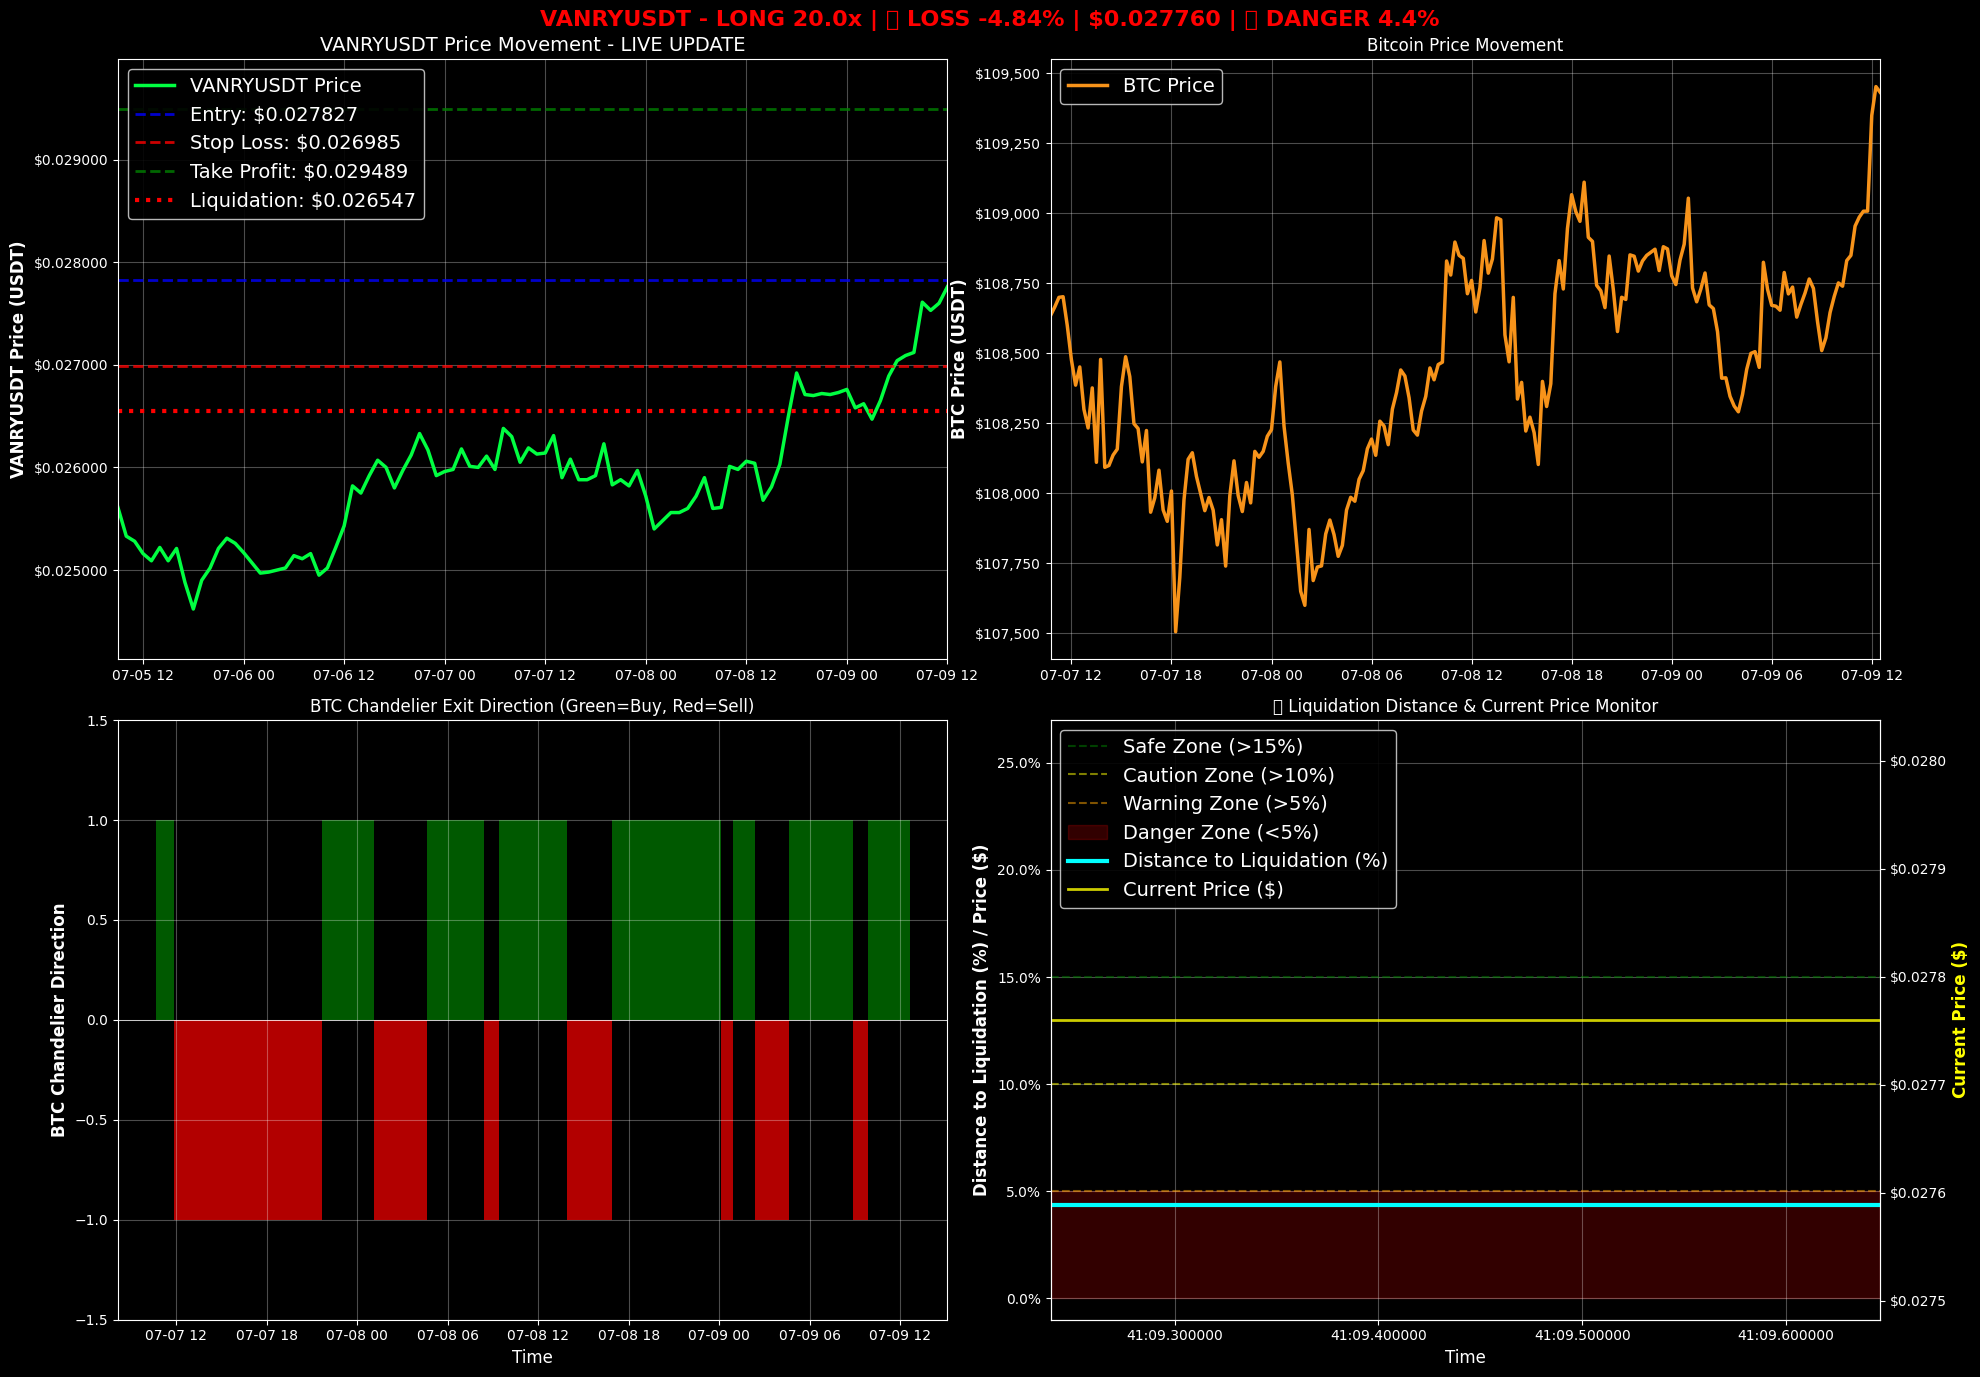

In [ ]:
from IPython.display import clear_output
from Display_Future import *
import time

try:
    while True:
        # clear last output before plotting the new one
        clear_output(wait=True)
        
        # call your real-time plotting function
        track_perpetual_trade_realtime(CSV_PATH, update_interval=5)
        
        # wait 10 seconds before the next update
        time.sleep(10)

except KeyboardInterrupt:
    print("Realtime tracking stopped by user.")


Loop_In_Bot

In [1]:
from SMC import *
from SMC_FGV import *
from Up_Down_Trend_Scanner import *

from IPython.display import clear_output
import time
import pandas as pd
from Chandelier_ZLSMA_Filter_Future import *
from Chandelier_ZLSMA import *
from Support_Resistance_Future_Scaner import *
from Display_Future import *
from Buy_Sell_Presure_Scaner import *

In [2]:
scanner = Binance_Support_Resistance_Perpetual_Scanner()
active_symbols = scanner.get_active_symbols()

In [3]:
downtrends = downtrend_scanner(active_symbols, timeframe='15m')

Scanning 445 symbols...
Progress: 10/445
Progress: 20/445
Progress: 30/445
Progress: 40/445
Progress: 50/445
Progress: 60/445
Progress: 70/445
Progress: 80/445
Progress: 90/445
Progress: 100/445
Progress: 110/445
Progress: 120/445
Progress: 130/445
Progress: 140/445
Progress: 150/445
Progress: 160/445
Progress: 170/445
Progress: 180/445
Progress: 190/445
Progress: 200/445
Progress: 210/445
Progress: 220/445
Progress: 230/445
Progress: 240/445
Progress: 250/445
Progress: 260/445
Progress: 270/445
Progress: 280/445
Progress: 290/445
Progress: 300/445
Progress: 310/445
Progress: 320/445
Progress: 330/445
Progress: 340/445
Progress: 350/445
Progress: 360/445
Progress: 370/445
Progress: 380/445
Progress: 390/445
Progress: 400/445
Progress: 410/445
Progress: 420/445
Progress: 430/445
Progress: 440/445


In [4]:
downtrends_ = downtrends[downtrends['downtrend_score'] >=  10]

In [5]:
downtrends_

,symbol,trend,score,uptrend_score,downtrend_score,current_price,price_change_5,price_change_10,rsi,volume_ratio,...,down_sma10_below_sma20,down_ema_bearish,down_rsi_bearish,down_macd_bearish,down_volume_decreasing_or_panic,down_lower_highs,down_below_bb_middle,down_momentum_weak,down_momentum_5_negative,down_momentum_10_negative
411,VELODROMEUSDT,DOWNTREND,11,0,11,0.046100,-0.43,-0.22,38.46,0.03,...,True,True,True,True,True,True,True,True,True,True
413,VICUSDT,DOWNTREND,11,0,11,0.291000,-0.65,-4.24,32.34,0.08,...,True,True,True,True,True,True,True,True,True,True
36,ALPINEUSDT,DOWNTREND,11,1,11,0.840000,-0.71,-3.23,50.00,0.05,...,True,True,True,True,True,True,True,True,True,True
46,ARKUSDT,DOWNTREND,11,0,11,0.398200,-0.05,-0.35,35.53,0.05,...,True,True,True,True,True,True,True,True,True,True
92,BSWUSDT,DOWNTREND,11,1,11,0.011200,-8.20,-9.68,17.14,5.31,...,True,True,True,True,True,True,True,True,True,True
98,CAKEUSDT,DOWNTREND,11,0,11,2.288000,-0.04,-0.17,32.50,0.31,...,True,True,True,True,True,True,True,True,True,True
100,CELOUSDT,DOWNTREND,11,0,11,0.306000,-0.62,-4.46,23.14,0.06,...,True,True,True,True,True,True,True,True,True,True
79,BIDUSDT,DOWNTREND,11,0,11,0.104420,-0.41,-0.22,27.63,0.06,...,True,True,True,True,True,True,True,True,True,True
84,BNBUSDT,DOWNTREND,11,0,11,659.570000,-0.09,-0.35,17.20,0.22,...,True,True,True,True,True,True,True,True,True,True
381,SXTUSDT,DOWNTREND,11,1,11,0.071900,-0.69,-1.64,35.90,0.00,...,True,True,True,True,True,True,True,True,True,True


In [6]:
perp_longs = get_long_signals(downtrends_['symbol'].to_list(), timeframe='15m', market_type='future')

✅ Initialized for Binance PERPETUAL CONTRACTS

🔍 Scanning 43 coins on FUTURE market...
Scanning FVG opportunities for VELODROMEUSDT (future)...
Scanning FVG opportunities for VICUSDT (future)...
Scanning FVG opportunities for ALPINEUSDT (future)...
Scanning FVG opportunities for ARKUSDT (future)...
Scanning FVG opportunities for BSWUSDT (future)...
Scanning FVG opportunities for CAKEUSDT (future)...
Scanning FVG opportunities for CELOUSDT (future)...
Scanning FVG opportunities for BIDUSDT (future)...
Scanning FVG opportunities for BNBUSDT (future)...
Scanning FVG opportunities for SXTUSDT (future)...
Scanning FVG opportunities for DEXEUSDT (future)...
Scanning FVG opportunities for SIGNUSDT (future)...
Scanning FVG opportunities for SYRUPUSDT (future)...
Scanning FVG opportunities for AVAAIUSDT (future)...
Scanning FVG opportunities for GPSUSDT (future)...
Scanning FVG opportunities for FIDAUSDT (future)...
Scanning FVG opportunities for PENGUUSDT (future)...
Scanning FVG opportunities

In [7]:
perp_longs

""
